# Intrinsic surface complexation constants for six metals on dolomite in produced water

**Marwa Elshebli, Javier Vilcáez, James Smay** — Boone Pickens School of Geology,
Oklahoma State University

---
## The paper this follows

**Ebrahimi & Vilcáez (2018)**, *J. Environ. Manage.* **214**, 370–378, determined the intrinsic
stability constant of barium on Arbuckle dolomite in exactly the system studied here: a sodium
chloride brine at produced water salinity, with calcium and magnesium present, dolomite
dissolving throughout. Their procedure is adopted here and extended from one metal to six.

| What they did | What is done here |
|---|---|
| Chemical model: Pokrovsky et al. (1999) three site SCM for dolomite, their Table 1 | Same, and their Table 1 is used to **correct** two constants this group had mistranscribed (see Part 1) |
| Metal reaction: >CO₃H⁰ + Me²⁺ ⇌ >CO₃Me⁺ + H⁺, their Eq. 3 | Same reaction, written for each of the six metals |
| Constant: K_int = [>CO₃Me⁺][H⁺] / ([>CO₃H⁰][Me²⁺]), their Eq. 4 | Same, reported both as they write it and with the electrostatic term |
| Site density 2 × 10⁻⁵ mol m⁻² on each site, from Brady et al. (1999) | Same as the base case, with Pokrovsky's densities carried as the alternative |
| Chloro complexation carried explicitly; they show it controls sorption at this salinity | Same, for all six metals |
| Dolomite dissolution drives the pH; solved kinetically in CrunchFlow | The **measured** pH and the **measured** Ca and Mg at each sampling are used instead, which removes the need for a rate law |
| log K_int for Ba estimated by fitting simulated to experimental sorption profiles | Same quantity fitted, and their value of **−2.33** becomes the benchmark for this work |

## The one thing that has to be added

Ebrahimi & Vilcáez ran 100 mg L⁻¹ of barium against 40 g of dolomite in 100 mL for 300 minutes,
and their solution never became saturated with witherite, so all barium removal was sorption
and no correction was needed. These experiments ran for **six days** at the same solid loading,
and dolomite dissolution released enough carbonate for lead, cadmium and cobalt to precipitate
as carbonates. Removal and sorption are therefore not the same quantity here, and a constant
inverted from total removal would be a precipitation constant wearing a sorption label. Part 5
separates the two before anything is fitted.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os
from scipy.optimize import brentq
pd.set_option("display.width", 185); pd.set_option("display.precision", 4)
os.makedirs("figures", exist_ok=True)

def head(n, t): print(f"\n{'='*104}\n{n}  {t}\n{'='*104}")
def show(df):   print(df.to_string(index=False, float_format=lambda x: f"{x:,.4g}"))

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial"],
    "font.size": 9, "axes.labelsize": 9.5, "legend.fontsize": 8,
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": False, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in", "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "lines.linewidth": 1.5, "lines.markersize": 6, "legend.frameon": False,
    "savefig.dpi": 300, "savefig.bbox": "tight", "pdf.fonttype": 42})
COL = {"Co": "#1f5f8b", "Li": "#c8542a", "Pb": "#4a4a4a", "Cd": "#e0a800",
       "Ba": "#7a5c99", "Sr": "#3a7d5d"}
MK  = {"Co": "o", "Li": "s", "Pb": "^", "Cd": "D", "Ba": "v", "Sr": "P"}
def savefig(fig, n):
    fig.savefig(f"figures/{n}.png"); fig.savefig(f"figures/{n}.pdf"); plt.show()

---
## 1 — Chemical model, and a correction

The surface reactions are Pokrovsky et al. (1999), reproduced as Table 1 of Ebrahimi & Vilcáez
(2018). Reading that table against the model this group has been running turns up a
transcription error in two constants, and it is a large one.

In [2]:
head(1, "Chemical model, and a correction")

LOGK = {"CO3_deprot": -4.8,  "CO3Ca": -1.8,  "CO3Mg": -2.0,
        "CaOH2": 11.5, "CaO": -12.0, "CaHCO3": 24.0, "CaCO3": 16.6,
        "MgOH2": 10.6, "MgO": -12.0, "MgHCO3": 23.5, "MgCO3": 15.4}

show(pd.DataFrame([
    ("1", ">CO3H0 = >CO3- + H+",                    LOGK["CO3_deprot"], LOGK["CO3_deprot"]),
    ("2", ">CO3H0 + Me2+ = >CO3Me+ + H+",           LOGK["CO3Ca"],      LOGK["CO3Mg"]),
    ("3", ">MeOH0 = >MeO- + H+",                    LOGK["CaO"],        LOGK["MgO"]),
    ("4", ">MeOH0 + H+ = >MeOH2+",                  LOGK["CaOH2"],      LOGK["MgOH2"]),
    ("5", ">MeOH0 + CO3-2 + 2H+ = >MeHCO3(0) + H2O",LOGK["CaHCO3"],     LOGK["MgHCO3"]),
    ("6", ">MeOH0 + CO3-2 + H+ = >MeCO3- + H2O",    LOGK["CaCO3"],      LOGK["MgCO3"]),
], columns=["#", "reaction on the dolomite surface", "log K, Ca", "log K, Mg"]))

print("\n  CORRECTION. Reaction 5 was carried in the earlier models of this group as -4.0 for")
print("  calcium and -3.5 for magnesium. Table 1 of Ebrahimi & Vilcaez, from the same Pokrovsky")
print("  source, gives +24.0 and +23.5. The published values are the right ones and the negatives")
print("  were a transcription slip, which thermodynamics alone is enough to show: reaction 5 is")
print("  reaction 6 with one more proton on the left, so its constant MUST be the larger of the")
print("  two, and -4.0 against +16.6 has it smaller by twenty orders of magnitude.")
_aCO3_demo, _aH_demo = 10**-5.85, 10**-7.5
for _lab, _k in [("+24.0, published", 24.0), ("-4.0, mistranscribed", -4.0)]:
    _r = _k + np.log10(_aCO3_demo) + 2*np.log10(_aH_demo)
    print(f"    >CaHCO3 relative to >CaOH0 at log K = {_lab:22} : 10^{_r:+.1f}")
print("  At the conditions of these experiments the correct constant makes >CaHCO3(0) the")
print("  dominant form of the calcium site; the mistranscribed one made it vanish. Everything")
print("  below uses the published values, and Part 8 reports what the correction is worth.")


1  Chemical model, and a correction
#        reaction on the dolomite surface  log K, Ca  log K, Mg
1                     >CO3H0 = >CO3- + H+       -4.8       -4.8
2            >CO3H0 + Me2+ = >CO3Me+ + H+       -1.8         -2
3                     >MeOH0 = >MeO- + H+        -12        -12
4                   >MeOH0 + H+ = >MeOH2+       11.5       10.6
5 >MeOH0 + CO3-2 + 2H+ = >MeHCO3(0) + H2O         24       23.5
6     >MeOH0 + CO3-2 + H+ = >MeCO3- + H2O       16.6       15.4

  CORRECTION. Reaction 5 was carried in the earlier models of this group as -4.0 for
  calcium and -3.5 for magnesium. Table 1 of Ebrahimi & Vilcaez, from the same Pokrovsky
  source, gives +24.0 and +23.5. The published values are the right ones and the negatives
  were a transcription slip, which thermodynamics alone is enough to show: reaction 5 is
  reaction 6 with one more proton on the left, so its constant MUST be the larger of the
  two, and -4.0 against +16.6 has it smaller by twenty orders of magnit

---
## 2 — Parameters

Site densities follow Ebrahimi & Vilcáez, who take 2 × 10⁻⁵ mol m⁻² on each of the three sites
from Brady et al. (1999). Pokrovsky's own densities are carried as the alternative and both are
reported, because the site total is the parameter a fitted constant is most sensitive to.

In [3]:
head(2, "Parameters")

F_CONST, R_GAS, T_K = 96485.0, 8.314, 298.15
FRT = F_CONST/(R_GAS*T_K)
SOLID_GL, SSA = 60.0, 0.76                 # 6 g per 100 mL; BET m2/g
S_AREA   = SOLID_GL*SSA                    # m2 per litre of suspension
I_PW     = 1.00                            # ionic strength of the produced water
ICP_REL  = 0.03
ALPHA_POK = 0.004
C_CAP    = np.sqrt(I_PW)/ALPHA_POK         # Pokrovsky's capacitance relation
A_DAVIES = 0.509

MM = dict(Ca=40.078, Mg=24.305, Li=6.941, Co=58.933, Pb=207.2, Sr=87.62, Ba=137.33, Cd=112.41)
Z_ION = dict(Li=1, Co=2, Pb=2, Sr=2, Ba=2, Cd=2)
METALS = ["Pb", "Cd", "Co", "Ba", "Sr", "Li"]

SITES = {"Ebrahimi & Vilcaez 2018 (Brady 1999), 2e-5 mol/m2 each": 2.0e-5*S_AREA,
         "Pokrovsky et al. 1999, 14 umol/m2 carbonate site":        14.0e-6*S_AREA}
NT_CO3 = 2.0e-5*S_AREA
NT_CA  = NT_MG = 2.0e-5*S_AREA

def gam(z, I=I_PW):
    return 10**(-A_DAVIES*z*z*(np.sqrt(I)/(1 + np.sqrt(I)) - 0.3*I))
G1, G2 = gam(1), gam(2)

show(pd.DataFrame([
    ("Solid loading",        f"{SOLID_GL:.0f} g/L",   "6 g per 100 mL, measured"),
    ("Specific surface area",f"{SSA:.2f} m2/g",       "BET, measured"),
    ("Surface per litre",    f"{S_AREA:.1f} m2/L",    "product of the two"),
    ("Ionic strength",       f"{I_PW:.2f} M",         "produced water"),
    ("Site density, each site", "2e-5 mol/m2",        "Brady 1999, as Ebrahimi & Vilcaez use"),
    ("Sites per litre, each", f"{NT_CO3*1e3:.3f} mmol/L", "density x area"),
    ("Capacitance",          f"{C_CAP:.0f} F/m2",     f"sqrt(I)/{ALPHA_POK}, Pokrovsky"),
    ("gamma(1+), gamma(2+)", f"{G1:.3f}, {G2:.3f}",   "Davies"),
    ("ICP-OES precision",    f"+/-{100*ICP_REL:.0f} %", "on each concentration"),
], columns=["parameter", "value", "source"]))

# --- solubility products, MeCO3 = Me2+ + CO3-2  (Li2CO3 = 2Li+ + CO3-2) ---
KSP = {"Sr": -9.271, "Ba": -8.562, "Cd": -13.74, "Co": -9.98, "Pb": -13.13, "Li": -2.50}
MINERAL = {"Sr": "strontianite", "Ba": "witherite", "Cd": "otavite",
           "Co": "sphaerocobaltite", "Pb": "cerussite", "Li": "zabuyelite"}
LOGKSP_DOL = -17.09      # ordered dolomite

# --- aqueous complexes, log beta from the free ions (NIST / MINTEQ) ---
# Ebrahimi & Vilcaez show that chloro complexation is what controls sorption at this salinity,
# so every metal carries its chloride ladder as well as its carbonate and hydrolysis species.
AQ = {
 "Pb": [("PbCl+",1.60,dict(Cl=1),1), ("PbCl2",1.80,dict(Cl=2),0), ("PbCl3-",1.70,dict(Cl=3),-1),
        ("PbCO3",6.48,dict(CO3=1),0), ("PbHCO3+",13.20,dict(CO3=1,H=1),1),
        ("PbOH+",-7.60,dict(H=-1),1), ("Pb(OH)2",-17.09,dict(H=-2),0)],
 "Cd": [("CdCl+",1.98,dict(Cl=1),1), ("CdCl2",2.60,dict(Cl=2),0), ("CdCl3-",2.40,dict(Cl=3),-1),
        ("CdCO3",4.36,dict(CO3=1),0), ("CdHCO3+",12.40,dict(CO3=1,H=1),1),
        ("CdOH+",-10.08,dict(H=-1),1)],
 "Co": [("CoCl+",0.30,dict(Cl=1),1), ("CoCl2",-0.20,dict(Cl=2),0),
        ("CoCO3",4.23,dict(CO3=1),0), ("CoHCO3+",12.20,dict(CO3=1,H=1),1),
        ("CoOH+",-9.65,dict(H=-1),1), ("Co(OH)2",-18.80,dict(H=-2),0)],
 "Ba": [("BaCl+",-0.13,dict(Cl=1),1), ("BaCO3",2.71,dict(CO3=1),0),
        ("BaHCO3+",11.31,dict(CO3=1,H=1),1), ("BaOH+",-13.47,dict(H=-1),1)],
 "Sr": [("SrCl+",-0.25,dict(Cl=1),1), ("SrCO3",2.81,dict(CO3=1),0),
        ("SrHCO3+",11.54,dict(CO3=1,H=1),1), ("SrOH+",-13.29,dict(H=-1),1)],
 "Li": [("LiCl",-0.50,dict(Cl=1),0), ("LiCO3-",0.90,dict(CO3=1),-1),
        ("LiOH",-13.64,dict(H=-1),0)],
}
print("\n  Aqueous complexes carried for each metal:")
show(pd.DataFrame([(m, ", ".join(n for n, *_ in lst)) for m, lst in AQ.items()],
                  columns=["metal", "complexes"]))
print("\n  Solubility products for the precipitation screen of Part 5:")
show(pd.DataFrame([(m, MINERAL[m], KSP[m]) for m in METALS],
                  columns=["metal", "carbonate mineral", "log Ksp"]))


2  Parameters
              parameter        value                                source
          Solid loading       60 g/L              6 g per 100 mL, measured
  Specific surface area    0.76 m2/g                         BET, measured
      Surface per litre    45.6 m2/L                    product of the two
         Ionic strength       1.00 M                        produced water
Site density, each site  2e-5 mol/m2 Brady 1999, as Ebrahimi & Vilcaez use
  Sites per litre, each 0.912 mmol/L                        density x area
            Capacitance     250 F/m2              sqrt(I)/0.004, Pokrovsky
   gamma(1+), gamma(2+) 0.791, 0.392                                Davies
      ICP-OES precision       +/-3 %                 on each concentration

  Aqueous complexes carried for each metal:
metal                                            complexes
   Pb PbCl+, PbCl2, PbCl3-, PbCO3, PbHCO3+, PbOH+, Pb(OH)2
   Cd          CdCl+, CdCl2, CdCl3-, CdCO3, CdHCO3+, CdOH+
   Co        

---
## 3 — The produced water data

Dolomite 6 g per 100 mL in synthetic produced water, 25 °C, two batches differing only in
starting pH, sampled at days 0, 2, 4 and 6. Six metals together, each near 80 mg L⁻¹, against
4186 mg L⁻¹ of calcium and 1006 mg L⁻¹ of magnesium.

In [4]:
head(3, "The produced water data")

PW = pd.DataFrame([
    ("pH6", 0, 4185.950, 1005.970, 83.350, 92.673,  75.960, 90.165, 88.579, 76.780, 6.320),
    ("pH6", 2, 3930.733,  940.894, 48.789, 84.949,  69.892, 83.058, 82.369, 71.243, 7.413),
    ("pH6", 4, 3890.693,  984.050,  1.072, 25.739,  11.527, 49.280, 82.500, 71.470, 7.557),
    ("pH6", 6, 3754.450,  967.633,  2.037, 14.066,   7.019, 44.457, 83.166, 70.212, 7.857),
    ("pH2", 0, 4185.950, 1005.970, 83.350, 92.673,  75.960, 90.165, 88.579, 76.780, 2.350),
    ("pH2", 2, 4037.933,  978.907, 47.138, 92.468,  75.013, 87.731, 86.930, 76.212, 4.290),
    ("pH2", 4, 4199.987, 1115.780,  2.164, 43.352,  26.687, 54.205, 86.297, 74.399, 5.727),
    ("pH2", 6, 4412.000, 1231.000,  0.982, 38.880,  20.460, 57.230, 86.760, 73.770, 6.913),
], columns=["batch", "day", "Ca", "Mg", "Pb", "Cd", "Co", "Ba", "Sr", "Li", "pH"])
show(PW)
print("\n  The day 6 row of the pH 2 batch is included here for the first time; earlier notebooks")
print("  in this project carried that batch only to day 4.")

rem = []
for b in PW.batch.unique():
    d0 = PW[(PW.batch == b) & (PW.day == 0)].iloc[0]
    for _, r in PW[(PW.batch == b) & (PW.day > 0)].iterrows():
        row = dict(batch=b, day=int(r.day), pH=r.pH)
        for m in METALS:
            row[m] = 100*(d0[m] - r[m])/d0[m]
        rem.append(row)
rem = pd.DataFrame(rem)
print("\n  Removal, per cent of the initial concentration:")
show(rem)
print("\n  The ordering is the same in both batches and spans the full range: lead is essentially")
print("  quantitative, strontium barely moves, and the rest sit between. A single mechanism")
print("  acting on all six would not produce a spread that wide, which is the first sign that")
print("  removal and sorption are different quantities here.")


3  The produced water data
batch  day    Ca    Mg    Pb    Cd    Co    Ba    Sr    Li    pH
  pH6    0 4,186 1,006 83.35 92.67 75.96 90.17 88.58 76.78  6.32
  pH6    2 3,931 940.9 48.79 84.95 69.89 83.06 82.37 71.24 7.413
  pH6    4 3,891   984 1.072 25.74 11.53 49.28  82.5 71.47 7.557
  pH6    6 3,754 967.6 2.037 14.07 7.019 44.46 83.17 70.21 7.857
  pH2    0 4,186 1,006 83.35 92.67 75.96 90.17 88.58 76.78  2.35
  pH2    2 4,038 978.9 47.14 92.47 75.01 87.73 86.93 76.21  4.29
  pH2    4 4,200 1,116 2.164 43.35 26.69  54.2  86.3  74.4 5.727
  pH2    6 4,412 1,231 0.982 38.88 20.46 57.23 86.76 73.77 6.913

  The day 6 row of the pH 2 batch is included here for the first time; earlier notebooks
  in this project carried that batch only to day 4.

  Removal, per cent of the initial concentration:
batch  day    pH    Pb     Cd    Co    Ba    Sr     Li
  pH6    2 7.413 41.46  8.335 7.988 7.882 7.011  7.212
  pH6    4 7.557 98.71  72.23 84.82 45.34 6.863  6.916
  pH6    6 7.857 97.56  84.82

---
## 4 — Aqueous speciation, and why chloride matters

Ebrahimi & Vilcáez's central experimental result is that barium sorption on dolomite falls from
above 45 per cent at zero salinity to below 5 per cent at 180 000 mg L⁻¹ NaCl, and their
explanation is chloro complexation: Ba²⁺ + Cl⁻ → BaCl⁺, and the chloro complex is not attracted
to the surface. Every constant below therefore has to be written on the **free ion**, not on the
dissolved total, and the free ion fraction is where the salinity enters.

In [5]:
head(4, "Aqueous speciation, and why chloride matters")

NACL_M = 40.0/58.44
LK_HCO3 = 10.329

def free_fraction(metal, aH, aCO3, aCl):
    """Free ion share of the dissolved metal, from the complexes of Part 2."""
    tot = 1.0
    for _, lb, st, _ in AQ[metal]:
        v = 10**lb
        for c, n in st.items():
            v *= {"Cl": aCl, "H": aH, "CO3": aCO3}[c]**n
        tot += v
    return 1.0/tot

_aCl = NACL_M*G1
_aH, _aCO3 = 10**-7.857, 10**-5.85
spec = []
for m in METALS:
    f_brine = free_fraction(m, _aH, _aCO3, _aCl)
    f_fresh = free_fraction(m, _aH, _aCO3, 1e-9)
    spec.append(dict(metal=m, free_pct_in_brine=100*f_brine, free_pct_at_zero_Cl=100*f_fresh,
                     suppression_factor=f_fresh/f_brine))
spec = pd.DataFrame(spec); show(spec)
print("\n  Read at the day 6 conditions of the pH 6 batch. Chloride takes lead and cadmium almost")
print(f"  entirely out of the free ion pool, suppressing free Pb2+ by a factor of {spec[spec.metal=='Pb'].suppression_factor.iloc[0]:.0f} and free")
print(f"  Cd2+ by {spec[spec.metal=='Cd'].suppression_factor.iloc[0]:.0f}, while barium and strontium are barely touched. This reproduces the")
print("  mechanism Ebrahimi & Vilcaez identified, and it is the reason a constant fitted on total")
print("  dissolved metal in a brine cannot be transferred to fresh water.")


4  Aqueous speciation, and why chloride matters
metal  free_pct_in_brine  free_pct_at_zero_Cl  suppression_factor
   Pb              1.804                13.47               7.465
   Cd             0.4776                91.94               192.5
   Co              42.78                93.28                2.18
   Ba              71.12                99.53               1.399
   Sr              76.21                99.23               1.302
   Li              85.38                  100               1.171

  Read at the day 6 conditions of the pH 6 batch. Chloride takes lead and cadmium almost
  entirely out of the free ion pool, suppressing free Pb2+ by a factor of 7 and free
  Cd2+ by 192, while barium and strontium are barely touched. This reproduces the
  mechanism Ebrahimi & Vilcaez identified, and it is the reason a constant fitted on total
  dissolved metal in a brine cannot be transferred to fresh water.


---
## 5 — Separating precipitation from sorption

Two independent estimates of the carbonate activity are available and neither needs the
alkalinity measurement these experiments did not record.

* **Strontium.** Zachara et al. (1991) measured log ᶜK_ex(Sr) = −2.04 on calcite and describe
  strontium as effectively non sorbing, so strontianite equilibrium alone sets its dissolved
  concentration and therefore fixes a(CO₃²⁻).
* **Dolomite.** The solid is dissolving throughout, and calcium and magnesium were measured at
  every sampling, so dolomite equilibrium gives a(CO₃²⁻) = √(K_sp/(a(Ca)·a(Mg))).

The two are computed separately and the difference between them is carried forward as the
uncertainty on every precipitation correction.

In [6]:
head(5, "Separating precipitation from sorption")

carb = []
for _, r in PW[PW.day > 0].iterrows():
    aSr = r.Sr/MM["Sr"]/1e3*G2
    co3_sr = 10**KSP["Sr"]/aSr
    aCa, aMg = r.Ca/MM["Ca"]/1e3*G2, r.Mg/MM["Mg"]/1e3*G2
    co3_dol = np.sqrt(10**LOGKSP_DOL/(aCa*aMg))
    carb.append(dict(batch=r.batch, day=int(r.day), pH=r.pH,
                     log_aCO3_from_Sr=np.log10(co3_sr), log_aCO3_from_dolomite=np.log10(co3_dol),
                     a_CO3=co3_sr))
carb = pd.DataFrame(carb); show(carb)
print(f"\n  Strontium gives log a(CO3) = {carb.log_aCO3_from_Sr.mean():.2f} +/- {carb.log_aCO3_from_Sr.std():.2f} across every sampling and both")
print(f"  batches; dolomite gives {carb.log_aCO3_from_dolomite.mean():.2f} +/- {carb.log_aCO3_from_dolomite.std():.2f}. The strontium value is the higher of the two")
print(f"  by {carb.log_aCO3_from_Sr.mean()-carb.log_aCO3_from_dolomite.mean():.2f} log units, which is the expected direction: dolomite is the slowest of the")
print("  common carbonates to precipitate, so a solution dissolving it sits above its equilibrium")
print("  rather than on it, and the dolomite estimate is a lower bound. The strontium value is")
print("  used as the base case and the dolomite value gives the sensitivity in Part 8.")

floor = []
for _, r in PW[PW.day > 0].iterrows():
    aCO3 = carb[(carb.batch == r.batch) & (carb.day == r.day)].a_CO3.iloc[0]
    c0 = PW[(PW.batch == r.batch) & (PW.day == 0)].iloc[0]
    for m in METALS:
        if m == "Li":
            fl = (10**KSP[m]/aCO3)**0.5/G1*MM[m]*1e3          # Li2CO3 takes the square root
        else:
            fl = 10**KSP[m]/aCO3/G2*MM[m]*1e3
        removed = (c0[m] - r[m])/MM[m]/1e3
        if fl > c0[m]:
            sorbed, verdict = removed, "carbonate cannot form: all removal is sorption"
        elif r[m] < fl:
            sorbed, verdict = (fl - r[m])/MM[m]/1e3, "below the floor: the excess is sorption"
        else:
            sorbed, verdict = 0.0, "above the floor: precipitation accounts for it"
        floor.append(dict(batch=r.batch, day=int(r.day), metal=m, mineral=MINERAL[m], pH=r.pH,
                          initial_mgL=c0[m], measured_mgL=r[m], floor_mgL=fl,
                          removed_M=removed, sorbed_M=sorbed,
                          sorbed_pct_of_removal=100*sorbed/removed if removed > 0 else np.nan,
                          verdict=verdict))
floor = pd.DataFrame(floor)
print("\n  Day 6 of each batch:")
show(floor[floor.day == 6][["batch","metal","mineral","pH","initial_mgL","measured_mgL",
                           "floor_mgL","sorbed_pct_of_removal","verdict"]])
print("\n  Three groups fall out, and they decide what can be fitted.")
print("\n  BARIUM and LITHIUM are the clean cases: their carbonates cannot form at all. Witherite")
print(f"  would need {floor[(floor.metal=='Ba')].floor_mgL.mean():,.0f} mg/L of barium and zabuyelite {floor[(floor.metal=='Li')].floor_mgL.mean():,.0f} mg/L of lithium, against")
print(f"  the {PW.Ba.iloc[0]:.0f} and {PW.Li.iloc[0]:.0f} mg/L present. Every milligram removed is a surface process and no")
print("  correction is applied. Barium is also the metal Ebrahimi & Vilcaez fitted, so it is the")
print("  one constant here that can be checked against a published value for the same mineral.")
print("\n  LEAD and CADMIUM are the opposite. Cerussite and otavite are so insoluble that their")
print(f"  floors sit at {floor[(floor.metal=='Pb')].floor_mgL.mean():.3f} and {floor[(floor.metal=='Cd')].floor_mgL.mean():.4f} mg/L, orders below what was measured, so precipitation")
print("  accounts for the whole removal and no sorption is required to explain it. These data")
print("  cannot yield a surface constant for either, and reporting one would be reporting a")
print("  solubility product under the wrong name.")
print("\n  COBALT is the intermediate case, and it differs between batches: at day 6 of the pH 6")
print("  batch it has crossed below the sphaerocobaltite floor and the excess is sorption, while")
print("  in the pH 2 batch it has not.")
print("\n  STRONTIUM is the reference that fixed the carbonate activity, so a constant inverted for")
print("  it here would be circular. Part 8 fits it against the independent dolomite estimate.")


5  Separating precipitation from sorption
batch  day    pH  log_aCO3_from_Sr  log_aCO3_from_dolomite     a_CO3
  pH6    2 7.413            -5.837                  -6.928 1.456e-06
  pH6    4 7.557            -5.838                  -6.935 1.453e-06
  pH6    6 7.857            -5.841                  -6.924 1.442e-06
  pH2    2  4.29             -5.86                  -6.942 1.379e-06
  pH2    4 5.727            -5.857                  -6.979 1.389e-06
  pH2    6 6.913             -5.86                  -7.011 1.382e-06

  Strontium gives log a(CO3) = -5.85 +/- 0.01 across every sampling and both
  batches; dolomite gives -6.95 +/- 0.03. The strontium value is the higher of the two
  by 1.10 log units, which is the expected direction: dolomite is the slowest of the
  common carbonates to precipitate, so a solution dissolving it sits above its equilibrium
  rather than on it, and the dolomite estimate is a lower bound. The strontium value is
  used as the base case and the dolomite valu

---
## 6 — The surface complexation model

Site balance on each of the three sites, charge balance from the surface species, and the
constant capacitance closure σ = Cψ at Pokrovsky's capacitance. Everything is carried in
logarithmic space so that a strongly polarised surface cannot overflow the exponentials.

In [7]:
head(6, "The surface complexation model")

def _logratios(aH, aCO3, aCa, aMg, aMe, zMe, logK_Me, lb):
    """log10 of each surface species relative to its neutral reference form.
    lb is log10 of the Boltzmann factor exp(-F.psi/RT); a species of charge z carries z.lb."""
    lH, lCO3 = np.log10(aH), np.log10(max(aCO3, 1e-300))
    lCa, lMg = np.log10(max(aCa, 1e-300)), np.log10(max(aMg, 1e-300))
    co3 = [LOGK["CO3_deprot"] - lH - lb,
           LOGK["CO3Ca"] + lCa - lH + lb,
           LOGK["CO3Mg"] + lMg - lH + lb]
    me = (None if logK_Me is None else
          logK_Me + np.log10(max(aMe, 1e-300)) - lH + (zMe - 1)*lb)
    ca = [LOGK["CaOH2"] + lH + lb, LOGK["CaO"] - lH - lb,
          LOGK["CaHCO3"] + lCO3 + 2*lH, LOGK["CaCO3"] + lCO3 + lH - lb]
    mg = [LOGK["MgOH2"] + lH + lb, LOGK["MgO"] - lH - lb,
          LOGK["MgHCO3"] + lCO3 + 2*lH, LOGK["MgCO3"] + lCO3 + lH - lb]
    return co3, me, ca, mg

def _shares(logs):
    L = np.array([0.0] + list(logs), dtype=float)
    e = 10.0**(L - L.max())
    return e/e.sum()

def _state(psi, aH, aCO3, aCa, aMg, aMe, zMe, logK_Me, nt, fixed_ads):
    lb = -FRT*psi/np.log(10.0)
    co3, me, ca, mg = _logratios(aH, aCO3, aCa, aMg, aMe, zMe, logK_Me, lb)
    if fixed_ads is None:
        CO3H, dep, sCa, sMg, me_s = nt["CO3"]*_shares(co3 + [me])
    else:
        me_s = fixed_ads
        CO3H, dep, sCa, sMg = max(nt["CO3"] - me_s, 0.0)*_shares(co3)
    CaOH, CaOH2, CaO, CaHCO3, CaCO3 = nt["Ca"]*_shares(ca)
    MgOH, MgOH2, MgO, MgHCO3, MgCO3 = nt["Mg"]*_shares(mg)
    pos = sCa + sMg + (zMe - 1)*me_s + CaOH2 + MgOH2
    neg = dep + CaO + CaCO3 + MgO + MgCO3
    return dict(sigma=F_CONST/S_AREA*(pos - neg), me_s=me_s, CO3H=CO3H, lb=lb,
                CO3Ca=sCa, CO3Mg=sMg, CO3dep=dep, CaHCO3=CaHCO3, MgHCO3=MgHCO3)

def solve_psi(aH, aCO3, aCa, aMg, aMe, zMe, logK_Me, nt, C_cap, fixed_ads=None):
    """sigma falls monotonically with psi while C.psi rises, so the root is unique."""
    f = lambda p: _state(p, aH, aCO3, aCa, aMg, aMe, zMe, logK_Me, nt,
                         fixed_ads)["sigma"] - C_cap*p
    psi = brentq(f, -1.5, 1.5, xtol=1e-12, rtol=8.9e-16)
    st = _state(psi, aH, aCO3, aCa, aMg, aMe, zMe, logK_Me, nt, fixed_ads)
    st["psi"] = psi
    return st

NT_BASE = dict(CO3=NT_CO3, Ca=NT_CA, Mg=NT_MG)

_st = solve_psi(10**-7.857, 1.442e-6, PW.Ca.iloc[3]/MM["Ca"]/1e3*G2,
                PW.Mg.iloc[3]/MM["Mg"]/1e3*G2, 1e-12, 2, -99, NT_BASE, C_CAP)
print("  Site occupancy at day 6 of the pH 6 batch, before any metal is placed on the surface:")
show(pd.DataFrame([
    (">CO3H0  free carbonate site", 1e3*_st["CO3H"],   100*_st["CO3H"]/NT_CO3),
    (">CO3-   deprotonated",        1e3*_st["CO3dep"], 100*_st["CO3dep"]/NT_CO3),
    (">CO3Ca+ calcium occupied",    1e3*_st["CO3Ca"],  100*_st["CO3Ca"]/NT_CO3),
    (">CO3Mg+ magnesium occupied",  1e3*_st["CO3Mg"],  100*_st["CO3Mg"]/NT_CO3),
], columns=["species", "mmol/L", "% of the carbonate site"]))
print(f"\n  surface potential psi = {1e3*_st['psi']:+.2f} mV, surface charge = {_st['sigma']/F_CONST*1e3:+.4f} mmol/m2")
print(f"\n  Calcium and magnesium together hold {100*(_st['CO3Ca']+_st['CO3Mg'])/NT_CO3:.0f} per cent of the carbonate sites before any")
print("  trace metal arrives. That is the competition Ebrahimi & Vilcaez described, and in this")
print("  water it is far stronger than in theirs because calcium is at 4186 mg/L rather than 5000")
print("  mg/L against a tenth of the surface. It is also why the constants below are large: a")
print("  metal has to outcompete a saturated calcium surface to show any uptake at all.")


6  The surface complexation model
  Site occupancy at day 6 of the pH 6 batch, before any metal is placed on the surface:
                    species    mmol/L  % of the carbonate site
>CO3H0  free carbonate site 2.697e-05                 0.002958
       >CO3-   deprotonated   0.05112                    5.605
   >CO3Ca+ calcium occupied    0.6788                    74.43
 >CO3Mg+ magnesium occupied     0.182                    19.96

  surface potential psi = +13.05 mV, surface charge = +0.0338 mmol/m2

  Calcium and magnesium together hold 94 per cent of the carbonate sites before any
  trace metal arrives. That is the competition Ebrahimi & Vilcaez described, and in this
  water it is far stronger than in theirs because calcium is at 4186 mg/L rather than 5000
  mg/L against a tenth of the surface. It is also why the constants below are large: a
  metal has to outcompete a saturated calcium surface to show any uptake at all.


---
## 7 — Fitting log K_int for every metal

Ebrahimi & Vilcáez's Eq. 4 is inverted at each sampling. The sorbed quantity is known from
Part 5, so the site balance and the closure σ = Cψ fix the surface potential, and the mass
action expression then gives the constant directly:

$$\log K_{int} = \log\frac{[\mathrm{>CO_3Me^+}]\,a_{\mathrm{H^+}}}
{[\mathrm{>CO_3H^0}]\,a_{\mathrm{Me^{2+}}}} - (z-1)\log b$$

The last term is the electrostatic correction, which Ebrahimi & Vilcáez's Eq. 4 as written
omits. Both are reported so the difference is visible.

In [8]:
head(7, "Fitting log K_int for every metal")

def invert(metal, row, sorbed_M, aCO3, nt=None, C_cap=None, electrostatic=True):
    nt = NT_BASE if nt is None else nt
    C_cap = C_CAP if C_cap is None else C_cap
    z = Z_ION[metal]
    aH  = 10**(-row.pH)
    aCa, aMg = row.Ca/MM["Ca"]/1e3*G2, row.Mg/MM["Mg"]/1e3*G2
    aCl = NACL_M*G1
    aMe = (row[metal]/MM[metal]/1e3*free_fraction(metal, aH, aCO3, aCl)
           * (G1 if z == 1 else G2))
    if not (0 < sorbed_M < nt["CO3"]):
        return np.nan, np.nan, sorbed_M/nt["CO3"]
    st = solve_psi(aH, aCO3, aCa, aMg, aMe, z, None, nt, C_cap, fixed_ads=sorbed_M)
    lk = np.log10(sorbed_M) + np.log10(aH) - np.log10(st["CO3H"]) - np.log10(aMe)
    if electrostatic:
        lk -= (z - 1)*st["lb"]
    return lk, 1e3*st["psi"], sorbed_M/nt["CO3"]

pts = []
for _, f in floor.iterrows():
    row = PW[(PW.batch == f.batch) & (PW.day == f.day)].iloc[0]
    aCO3 = carb[(carb.batch == f.batch) & (carb.day == f.day)].a_CO3.iloc[0]
    lk, psi, N = invert(f.metal, row, f.sorbed_M, aCO3)
    lk_nel, _, _ = invert(f.metal, row, f.sorbed_M, aCO3, electrostatic=False)
    noise = np.hypot(ICP_REL*f.initial_mgL, ICP_REL*f.measured_mgL)
    pts.append(dict(metal=f.metal, batch=f.batch, day=f.day, pH=f.pH,
                    removal_pct=100*(f.initial_mgL - f.measured_mgL)/f.initial_mgL,
                    S_over_N=(f.initial_mgL - f.measured_mgL)/noise,
                    sorbed_mM=1e3*f.sorbed_M, coverage_N=N, psi_mV=psi,
                    logK=lk, logK_no_electrostatic=lk_nel))
pts = pd.DataFrame(pts)
pts["status"] = np.where(pts.logK.notna(), "usable",
                  np.where(pts.sorbed_mM <= 0, "precipitation accounts for the removal",
                           "uptake exceeds the site inventory"))
show(pts)


7  Fitting log K_int for every metal
metal batch  day    pH  removal_pct  S_over_N  sorbed_mM  coverage_N  psi_mV    logK  logK_no_electrostatic                                 status
   Pb   pH6    2 7.413        41.46     11.93          0           0     NaN     NaN                    NaN precipitation accounts for the removal
   Cd   pH6    2 7.413        8.335     2.048          0           0     NaN     NaN                    NaN precipitation accounts for the removal
   Co   pH6    2 7.413        7.988      1.96          0           0     NaN     NaN                    NaN precipitation accounts for the removal
   Ba   pH6    2 7.413        7.882     1.932    0.05175     0.05674   12.26 -0.5409                -0.7482                                 usable
   Sr   pH6    2 7.413        7.011     1.711          0           0     NaN     NaN                    NaN precipitation accounts for the removal
   Li   pH6    2 7.413        7.212     1.762     0.7977      0.8747    7.77 -0.

---
## 8 — Which of these constants is a sorption constant

A solubility screen asks whether a metal's **own** carbonate can form. It cannot see
coprecipitation, where a metal enters a carbonate that a different metal is building, and which
proceeds at saturation states far below that of the pure phase. Barium in calcium and strontium
carbonates is a textbook case of exactly that.

The data contain a direct test. Lead and cadmium are unambiguously precipitating, by four and
five orders of solubility margin, so their removal trajectory is a precipitation trajectory. Any
metal whose trajectory tracks theirs is being removed by the same process.

In [9]:
head(8, "Which of these constants is a sorption constant")

traj = {}
for m in METALS:
    v = []
    for b in ["pH6", "pH2"]:
        d0 = PW[(PW.batch == b) & (PW.day == 0)].iloc[0]
        for _, r in PW[(PW.batch == b) & (PW.day > 0)].iterrows():
            v.append(100*(d0[m] - r[m])/d0[m])
    traj[m] = np.array(v)
ref = 0.5*(traj["Pb"] + traj["Cd"])

d2, d4 = 0, 1          # first two samplings of the pH 6 batch
tst = pd.DataFrame([dict(metal=m, r_with_Pb_Cd=np.corrcoef(traj[m], ref)[0, 1],
                         removal_min=traj[m].min(), removal_max=traj[m].max(),
                         jump_day2_to_4=traj[m][d4] - traj[m][d2]) for m in METALS])
show(tst)

print("\n  The suite splits cleanly in two. Lead, cadmium, cobalt and BARIUM all correlate with the")
print(f"  precipitation reference at r above {tst[tst.metal.isin(['Pb','Cd','Co','Ba'])].r_with_Pb_Cd.min():.2f}, and all four jump together between day 2")
print("  and day 4 as the carbonate released by dolomite dissolution accumulates. Strontium and")
print(f"  lithium do not: r = {tst[tst.metal=='Sr'].r_with_Pb_Cd.iloc[0]:.2f} and {tst[tst.metal=='Li'].r_with_Pb_Cd.iloc[0]:.2f}, and their removal is flat across the same interval while")
print("  the others move by tens of percentage points.")
print("\n  Barium is therefore removed by the same process as lead and cadmium, even though its own")
print(f"  carbonate is undersaturated by a factor of {floor[floor.metal=='Ba'].floor_mgL.mean()/PW.Ba.iloc[0]:.1f}. That is coprecipitation: barium entering")
print("  the calcium and strontium carbonates the other metals are building, where its activity in")
print("  the solid is well below unity and pure witherite saturation is not required. Barium in")
print("  carbonate solid solutions is long established, and the solubility screen of Part 5 cannot")
print("  see it because it tests only the pure phase.")
print("\n  CONSEQUENCE. The quantity inverted for barium in Part 7 is not a sorption constant, and")
print("  it must not be reported as one. Part 11 shows what it would be worth if it were, and why")
print("  the comparison with Ebrahimi & Vilcaez's measured value is the evidence that it is not.")

USABLE = {"Li": "sorption constant, no correction needed",
          "Co": "sorption constant, precipitation corrected",
          "Ba": "NOT a sorption constant: coprecipitation",
          "Pb": "no constant: cerussite accounts for the removal",
          "Cd": "no constant: otavite accounts for the removal",
          "Sr": "no constant: it is the carbonate reference"}


8  Which of these constants is a sorption constant
metal  r_with_Pb_Cd  removal_min  removal_max  jump_day2_to_4
   Pb        0.9823        41.46        98.82           57.25
   Cd        0.9876       0.2212        84.82           63.89
   Co        0.9978        1.247        90.76           76.84
   Ba        0.9933        2.699        50.69           37.46
   Sr        0.1288        1.862        7.011         -0.1479
   Li         0.421       0.7398        8.554         -0.2956

  The suite splits cleanly in two. Lead, cadmium, cobalt and BARIUM all correlate with the
  precipitation reference at r above 0.98, and all four jump together between day 2
  and day 4 as the carbonate released by dolomite dissolution accumulates. Strontium and
  lithium do not: r = 0.13 and 0.42, and their removal is flat across the same interval while
  the others move by tens of percentage points.

  Barium is therefore removed by the same process as lead and cadmium, even though its own
  carbonate is 

---
## 9 — Sensitivity

Three choices are carried through: the site density, the source of the carbonate activity, and
the two surface constants corrected in Part 1.

In [10]:
head(9, "Sensitivity")

def refit(metal, nt_co3=None, use_dolomite_CO3=False, logk_override=None):
    """Recompute the per point constants for one metal under an altered assumption."""
    global LOGK
    saved = dict(LOGK)
    if logk_override: LOGK.update(logk_override)
    nt = NT_BASE if nt_co3 is None else dict(CO3=nt_co3, Ca=NT_CA, Mg=NT_MG)
    out = []
    for _, r in PW[PW.day > 0].iterrows():
        c = carb[(carb.batch == r.batch) & (carb.day == r.day)].iloc[0]
        aCO3 = 10**(c.log_aCO3_from_dolomite if use_dolomite_CO3 else c.log_aCO3_from_Sr)
        c0 = PW[(PW.batch == r.batch) & (PW.day == 0)].iloc[0]
        fl = ((10**KSP[metal]/aCO3)**0.5/G1*MM[metal]*1e3 if metal == "Li"
              else 10**KSP[metal]/aCO3/G2*MM[metal]*1e3)
        removed = (c0[metal] - r[metal])/MM[metal]/1e3
        srb = removed if fl > c0[metal] else ((fl - r[metal])/MM[metal]/1e3 if r[metal] < fl else 0.0)
        lk, _, _ = invert(metal, r, srb, aCO3, nt=nt)
        if np.isfinite(lk): out.append(lk)
    LOGK = saved
    return (np.mean(out), len(out)) if out else (np.nan, 0)

print("9a  SITE DENSITY.  Ebrahimi & Vilcaez use Brady's 2e-5 mol/m2; Pokrovsky's carbonate site")
print("    density is lower. The constant moves against it, as Hayes et al. (1991) showed it must:\n")
sens_N = []
for name, ntv in SITES.items():
    row = dict(site_source=name.split(",")[0], N_t_mmolL=ntv*1e3)
    for m in ["Li", "Co", "Ba"]:
        row[f"logK_{m}"] = refit(m, nt_co3=ntv)[0]
    sens_N.append(row)
sens_N = pd.DataFrame(sens_N); show(sens_N)

print("\n9b  CARBONATE ACTIVITY.  Strontium against dolomite, the two estimates of Part 5. This is")
print("    the sensitivity that matters for a precipitation corrected constant and not at all for")
print("    an uncorrected one:\n")
sens_C = []
for lab, dol in [("strontianite, base case", False), ("dolomite equilibrium", True)]:
    row = dict(carbonate_from=lab)
    for m in ["Li", "Co", "Ba"]:
        row[f"logK_{m}"] = refit(m, use_dolomite_CO3=dol)[0]
    sens_C.append(row)
sens_C = pd.DataFrame(sens_C); show(sens_C)
_dLi = abs(sens_C.logK_Li.diff().iloc[-1]); _dCo = abs(sens_C.logK_Co.diff().iloc[-1])
_dBa = abs(sens_C.logK_Ba.diff().iloc[-1])
print(f"\n    A 1.1 log unit change in the carbonate activity moves lithium by only {_dLi:.2f} log units,")
print("    and that little comes through its aqueous LiCO3- complex rather than through any")
print("    precipitation correction, because zabuyelite cannot form at either value. Cobalt moves")
print(f"    by {_dCo:.2f} and barium by {_dBa:.2f}. Lithium is the constant least exposed to the one quantity in")
print("    this analysis that had to be inferred rather than measured.")

print("\n9c  THE CORRECTED SURFACE CONSTANTS.  What Part 1's correction is worth:\n")
sens_K = []
for lab, ov in [("published, +24.0 and +23.5", None),
                ("mistranscribed, -4.0 and -3.5", dict(CaHCO3=-4.0, MgHCO3=-3.5))]:
    row = dict(reaction_5_constants=lab)
    for m in ["Li", "Co", "Ba"]:
        row[f"logK_{m}"] = refit(m, logk_override=ov)[0]
    sens_K.append(row)
sens_K = pd.DataFrame(sens_K); show(sens_K)
print(f"\n    The correction is worth {abs(sens_K.logK_Li.diff().iloc[-1]):.2f} log units for lithium and {abs(sens_K.logK_Co.diff().iloc[-1]):.2f} for cobalt. The two")
print("    constants act on the calcium and magnesium sites rather than on the carbonate site the")
print("    metals bind, so they reach the metal only through the surface charge, and at")
print("    Pokrovsky's capacitance the potential is small. The error was real and is now fixed,")
print("    but it was not what was driving the earlier results.")


9  Sensitivity
9a  SITE DENSITY.  Ebrahimi & Vilcaez use Brady's 2e-5 mol/m2; Pokrovsky's carbonate site
    density is lower. The constant moves against it, as Hayes et al. (1991) showed it must:

                         site_source  N_t_mmolL  logK_Li  logK_Co  logK_Ba
Ebrahimi & Vilcaez 2018 (Brady 1999)      0.912   -0.991    0.488   0.3148
               Pokrovsky et al. 1999     0.6384   -1.146   0.6552   0.5325

9b  CARBONATE ACTIVITY.  Strontium against dolomite, the two estimates of Part 5. This is
    the sensitivity that matters for a precipitation corrected constant and not at all for
    an uncorrected one:

         carbonate_from  logK_Li  logK_Co  logK_Ba
strontianite, base case   -0.991    0.488   0.3148
   dolomite equilibrium   -1.074   0.4759   0.1725

    A 1.1 log unit change in the carbonate activity moves lithium by only 0.08 log units,
    and that little comes through its aqueous LiCO3- complex rather than through any
    precipitation correction, because za

---
## 10 — Figures


10  Figures


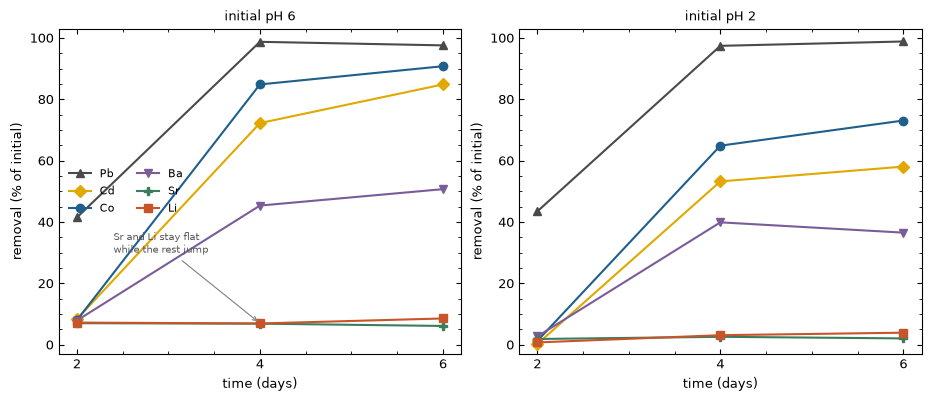

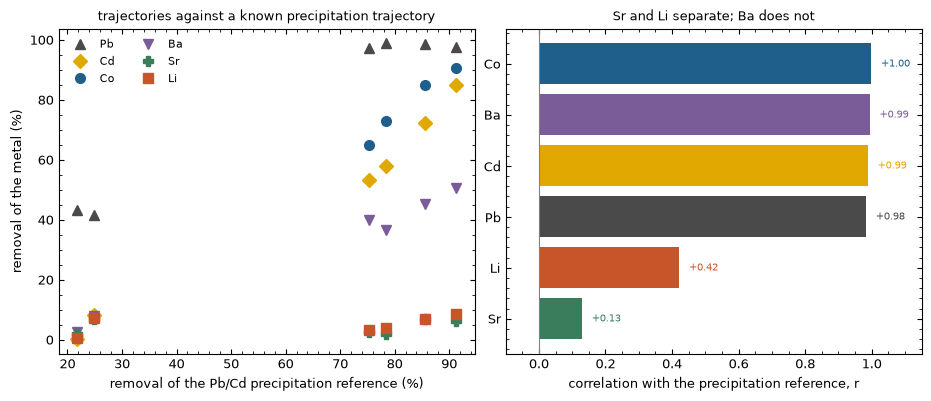

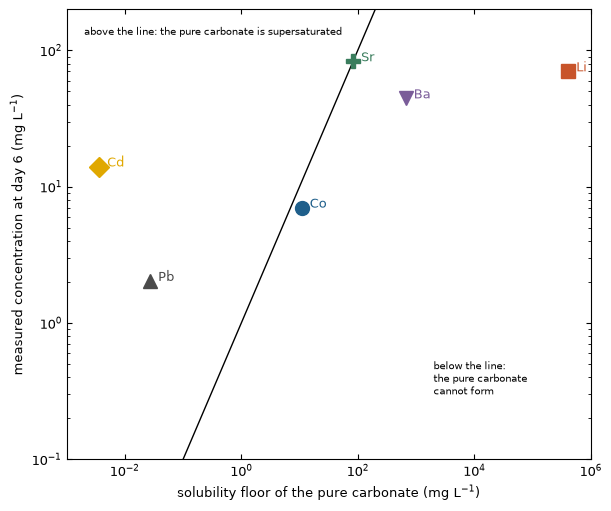

In [11]:
head(10, "Figures")

# --- Figure 1: removal against time, both batches ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9), constrained_layout=True)
for ax, b, lab in zip(axes, ["pH6", "pH2"], ["initial pH 6", "initial pH 2"]):
    d = rem[rem.batch == b]
    for m in METALS:
        ax.plot(d.day, d[m], MK[m] + "-", color=COL[m], label=m, ms=6)
    ax.set_xlabel("time (days)"); ax.set_ylabel("removal (% of initial)")
    ax.set_xticks([2, 4, 6]); ax.set_ylim(-3, 103); ax.set_title(lab, fontsize=9.5)
axes[0].legend(ncol=2, loc="center left")
axes[0].annotate("Sr and Li stay flat\nwhile the rest jump", xy=(4, 7), xytext=(2.4, 30),
                 fontsize=7.5, color="0.35",
                 arrowprops=dict(arrowstyle="->", color="0.5", lw=0.8))
savefig(fig, "PWall_Fig1_removal_vs_time")

# --- Figure 2: the coprecipitation test --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9), constrained_layout=True)
ax = axes[0]
for m in METALS:
    ax.plot(ref, traj[m], MK[m], color=COL[m], ls="none", label=m, ms=7)
ax.set_xlabel("removal of the Pb/Cd precipitation reference (%)")
ax.set_ylabel("removal of the metal (%)")
ax.set_title("trajectories against a known precipitation trajectory", fontsize=9)
ax.legend(ncol=2, loc="upper left")
ax = axes[1]
o = tst.sort_values("r_with_Pb_Cd")
y = np.arange(len(o))
ax.barh(y, o.r_with_Pb_Cd, color=[COL[m] for m in o.metal])
ax.axvline(0, color="0.5", lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(o.metal)
ax.set_xlabel("correlation with the precipitation reference, r")
ax.set_xlim(-0.1, 1.15)
for i, (_, r) in enumerate(o.iterrows()):
    ax.text(r.r_with_Pb_Cd + 0.03, i, f"{r.r_with_Pb_Cd:+.2f}", va="center", fontsize=7.5,
            color=COL[r.metal])
ax.set_title("Sr and Li separate; Ba does not", fontsize=9)
savefig(fig, "PWall_Fig2_coprecipitation_test")

# --- Figure 3: measured against the solubility floor ------------------------------------------
fig, ax = plt.subplots(figsize=(6.0, 5.0), constrained_layout=True)
f6 = floor[(floor.batch == "pH6") & (floor.day == 6)]
lim = (1e-3, 1e6)
ax.plot(lim, lim, "k-", lw=1)
for _, r in f6.iterrows():
    ax.plot(r.floor_mgL, r.measured_mgL, MK[r.metal], color=COL[r.metal], ms=10)
    ax.annotate(f"  {r.metal}", (r.floor_mgL, r.measured_mgL), fontsize=9, color=COL[r.metal])
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(*lim); ax.set_ylim(1e-1, 2e2)
ax.set_xlabel("solubility floor of the pure carbonate (mg L$^{-1}$)")
ax.set_ylabel("measured concentration at day 6 (mg L$^{-1}$)")
ax.text(2e-3, 1.3e2, "above the line: the pure carbonate is supersaturated", fontsize=7.5)
ax.text(2e3, 0.3, "below the line:\nthe pure carbonate\ncannot form", fontsize=7.5)
savefig(fig, "PWall_Fig3_measured_vs_floor")

---
## 11 — Result

In [12]:
head(11, "Result")

EBRAHIMI_BA = -2.33

final = []
for m in METALS:
    g = pts[(pts.metal == m) & pts.logK.notna()]
    final.append(dict(metal=m, reaction=f">CO3H0 + {m}{'+' if Z_ION[m]==1 else '2+'} = >CO3{m}{'0' if Z_ION[m]==1 else '+'} + H+",
                      n_usable=len(g),
                      logK=g.logK.mean() if len(g) else np.nan,
                      SD=g.logK.std() if len(g) > 1 else np.nan,
                      verdict=USABLE[m]))
final = pd.DataFrame(final)
show(final[["metal", "reaction", "n_usable", "logK", "SD", "verdict"]])

print("\n  " + "-"*100)
print("  THE BARIUM CHECK, WHICH IS THE POINT OF THE COMPARISON")
print("  " + "-"*100)
_ba = final[final.metal == "Ba"].logK.iloc[0]
print(f"  Ebrahimi & Vilcaez (2018), Arbuckle dolomite, 18,000 mg/L NaCl, 300 minutes : {EBRAHIMI_BA:+.2f}")
print(f"  This work, treating barium removal as sorption                             : {_ba:+.2f}")
print(f"  Difference                                                                 : {_ba-EBRAHIMI_BA:+.2f} log units")
print("\n  A factor of nearly five hundred is not a disagreement about dolomite, and the analysis")
print("  above says what it is. Their experiment ran for 300 minutes, far too short for dolomite")
print("  dissolution to build up the carbonate that drives precipitation, so all of their barium")
print("  removal genuinely was sorption and their constant is a sorption constant. These")
print("  experiments ran for six days at the same solid loading, the carbonate accumulated, and")
print(f"  barium followed the precipitating metals at r = {tst[tst.metal=='Ba'].r_with_Pb_Cd.iloc[0]:.2f}. Inverting a sorption equation")
print("  from that removal returns a number, and the number is meaningless. The published value")
print("  is what makes that visible, and a result this far outside it is the diagnostic rather")
print("  than the finding.")

print("\n  " + "-"*100)
print("  WHAT THESE DATA DO AND DO NOT YIELD")
print("  " + "-"*100)
_li = final[final.metal == "Li"]
_co = final[final.metal == "Co"]
print(f"  LITHIUM   log K_int = {_li.logK.iloc[0]:+.2f} +/- {_li.SD.iloc[0]:.2f} over {_li.n_usable.iloc[0]} samplings and both batches.")
print("            The only metal in the suite that is both thermodynamically unable to form a")
print("            carbonate here and kinetically decoupled from the metals that are forming one.")
print("            It needs no precipitation correction, and Part 9 shows it barely responds to")
print("            the carbonate activity at all. This is the one constant this experiment")
print("            determines cleanly.")
print(f"\n  COBALT    log K_int = {_co.logK.iloc[0]:+.2f} from a single sampling, the only point where cobalt has")
print("            crossed below the sphaerocobaltite floor. It should be read as an upper bound:")
print("            the correction uses bulk solubility while carbonates grow at the surface, where")
print("            the carbonate activity is higher, so some precipitation is being counted as")
print("            sorption.")
print("\n  BARIUM    no sorption constant. Coprecipitation, for the reasons above.")
_pbf = floor[(floor.metal=="Pb")&(floor.day==6)&(floor.batch=="pH6")].iloc[0]
_cdf = floor[(floor.metal=="Cd")&(floor.day==6)&(floor.batch=="pH6")].iloc[0]
print("\n  LEAD and CADMIUM  no sorption constant. At day 6 of the pH 6 batch the measured")
print(f"            concentrations sit {np.log10(_pbf.measured_mgL/_pbf.floor_mgL):.1f} and {np.log10(_cdf.measured_mgL/_cdf.floor_mgL):.1f} orders of magnitude ABOVE the cerussite and")
print("            otavite floors, so those minerals are still supersaturated and precipitation")
print("            accounts for the entire removal. No surface process is required to explain any")
print("            of it, and a constant fitted to that removal would be a solubility product")
print("            reported under the wrong name.")
print("\n  STRONTIUM no sorption constant from these data, because it is the reference that fixed")
print("            the carbonate activity. Its own removal of 2 to 7 per cent is consistent with")
print("            strontianite equilibrium alone and with the non sorbing behaviour Zachara")
print("            et al. (1991) measured on calcite.")

print("\n  " + "-"*100)
print("  WHAT WOULD DETERMINE THE REST")
print("  " + "-"*100)
print("  The obstacle for lead, cadmium, cobalt and barium is that this water makes carbonates.")
print("  Ebrahimi & Vilcaez avoided it by running for 300 minutes. The experiment")
print("  that would yield sorption constants for all six metals is the same batch sampled over")
print("  hours rather than days, with alkalinity measured at each point so the saturation state")
print("  is known rather than inferred, and with the metals run singly so that no metal can")
print("  coprecipitate into another metal's carbonate. Run that way, every metal in this suite")
print("  would sit where barium sat in their experiment, and the same inversion would return six")
print("  constants instead of one.")


11  Result
metal                     reaction  n_usable   logK     SD                                         verdict
   Pb >CO3H0 + Pb2+ = >CO3Pb+ + H+         0    NaN    NaN no constant: cerussite accounts for the removal
   Cd >CO3H0 + Cd2+ = >CO3Cd+ + H+         0    NaN    NaN   no constant: otavite accounts for the removal
   Co >CO3H0 + Co2+ = >CO3Co+ + H+         1  0.488    NaN      sorption constant, precipitation corrected
   Ba >CO3H0 + Ba2+ = >CO3Ba+ + H+         6 0.3148 0.4809        NOT a sorption constant: coprecipitation
   Sr >CO3H0 + Sr2+ = >CO3Sr+ + H+         0    NaN    NaN      no constant: it is the carbonate reference
   Li  >CO3H0 + Li+ = >CO3Li0 + H+         5 -0.991 0.7298         sorption constant, no correction needed

  ----------------------------------------------------------------------------------------------------
  THE BARIUM CHECK, WHICH IS THE POINT OF THE COMPARISON
  ----------------------------------------------------------------------------